In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)



In [2]:
# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos predictores según antecedentes médicos [7, 8]
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de variable categórica 'Sex' (M=0, F=1)
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# 0 = "non demented" (CDR 0), 1 = "demented" (CDR >= 0.5)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (Crítico en SES y Educación) [5, 9]
# Se utiliza la mediana para no sesgar las distribuciones ante valores extremos.
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)



/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Ejecutando 10 iteraciones de validación independiente para Random Forest...


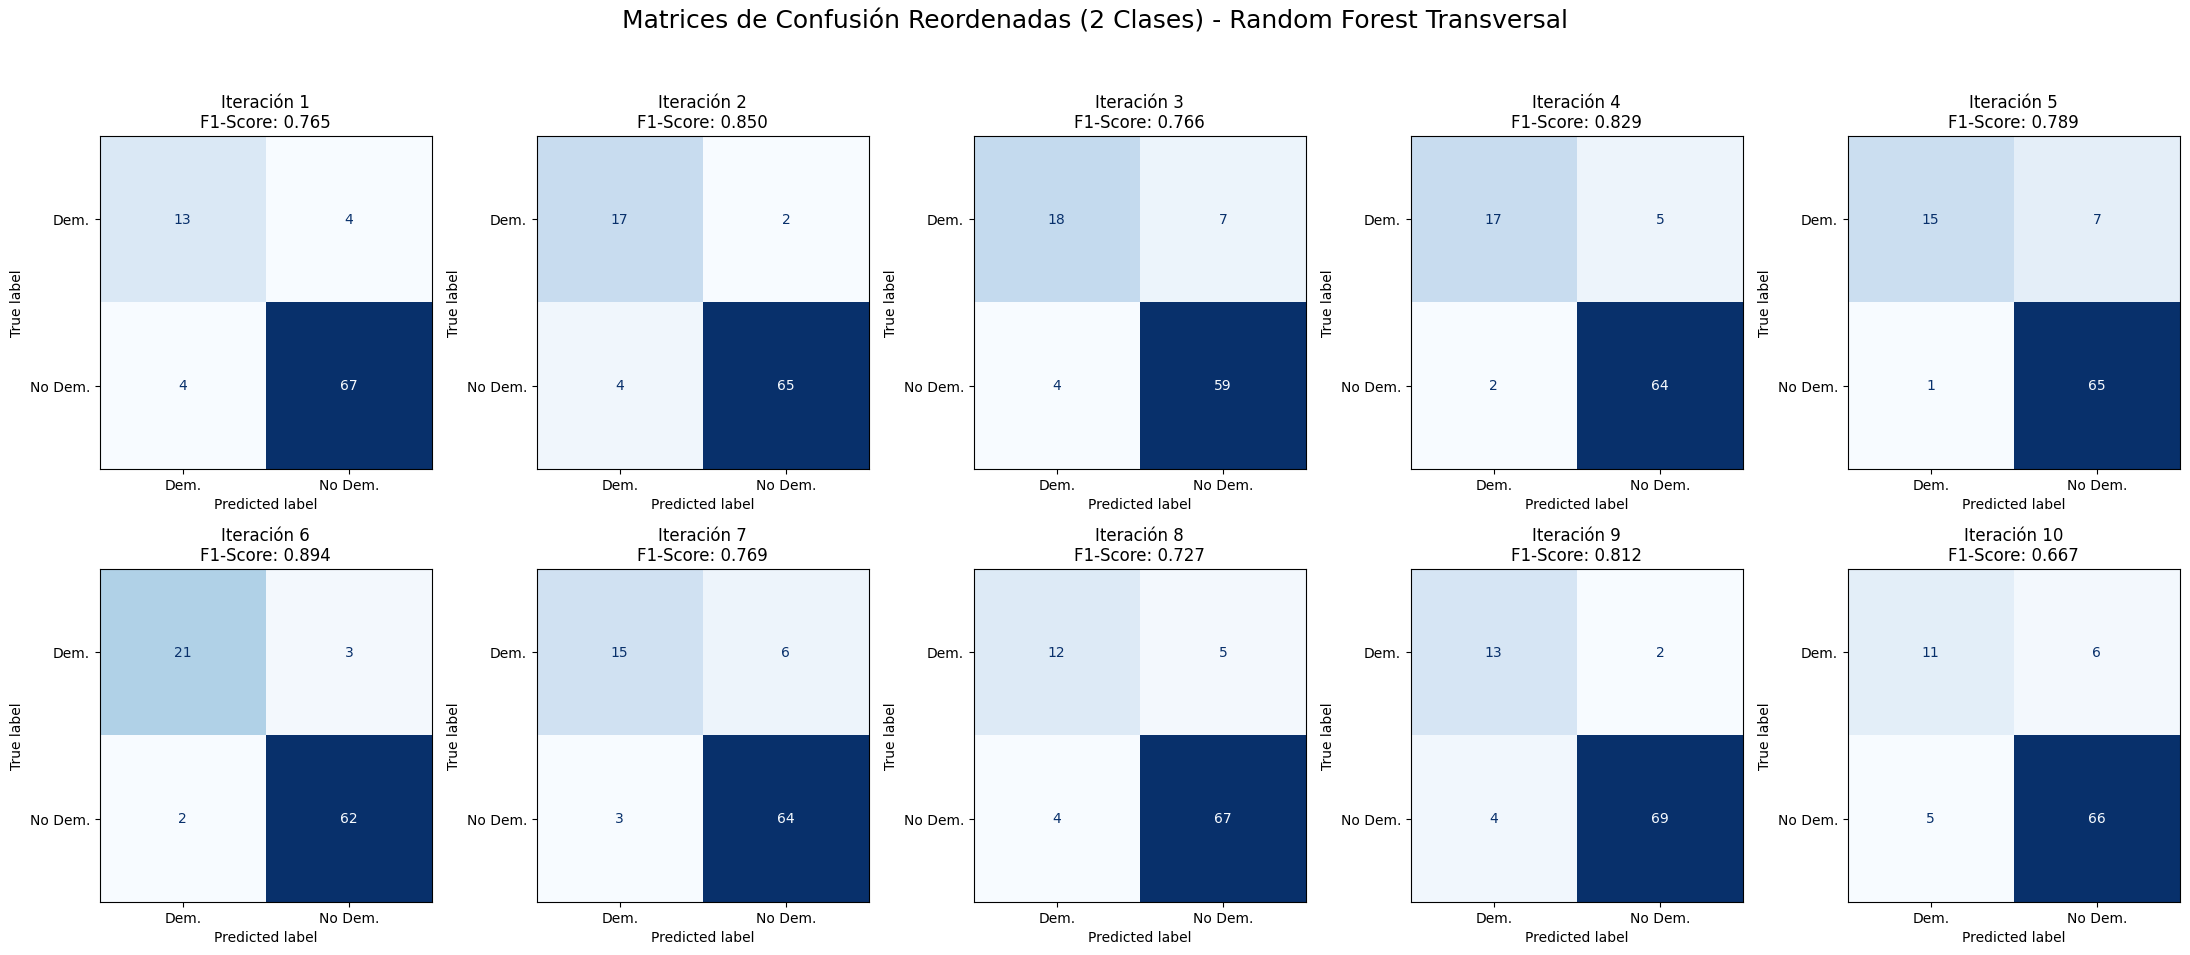

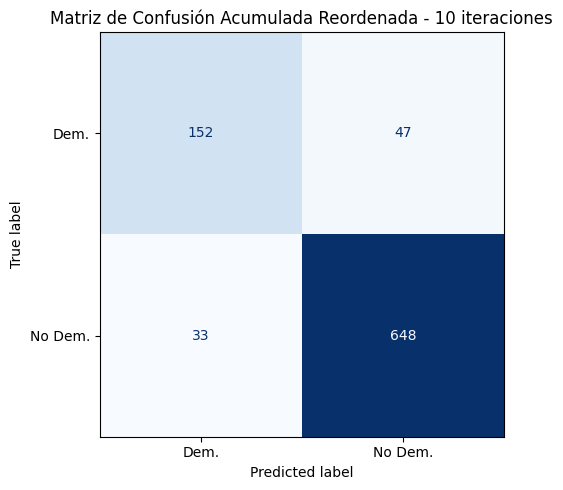


--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.9091 ± 0.0222
PREC                      | 0.8173 ± 0.0754
REC                       | 0.7643 ± 0.0826
F1                        | 0.7869 ± 0.0609
AUC                       | 0.9631 ± 0.0149


In [3]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20 [3]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para Random Forest...")

for i in range(10):
    # Partición aleatoria única por iteración (80% entrenamiento / 20% prueba)
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Implementación del Modelo Random Forest
    # n_estimators=100 como base recomendada por la guía [10].
    # class_weight='balanced' para mitigar el desbalance entre sanos y dementes [11].
    rf = RandomForestClassifier(n_estimators=100, 
                                class_weight='balanced', 
                                random_state=42)
    rf.fit(X_train, y_train)
    
    # Predicciones y probabilidades
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]
    
    # 5. Registro de Métricas de Desempeño [12]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Generación de Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1-Score: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - Random Forest Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE) [13]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Evaluando n_estimators...


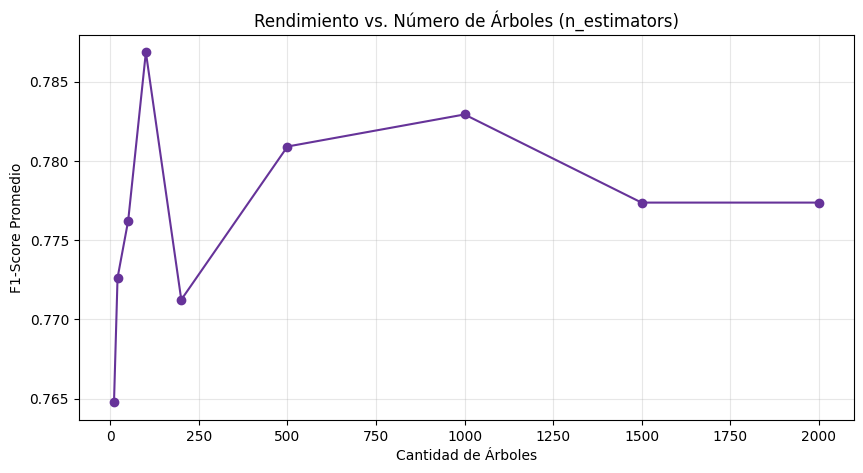

El n_estimators recomendado es: 100


In [4]:
n_values = [10, 20, 50, 100, 200, 500, 1000, 1500, 2000]
scores_n = []

print("Evaluando n_estimators...")
for n in n_values:
    iter_scores = []
    for i in range(10): # 10 Validaciones independientes
        Xt, Xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
        rf.fit(Xt, yt)
        iter_scores.append(f1_score(yv, rf.predict(Xv)))
    scores_n.append(np.mean(iter_scores))

plt.figure(figsize=(10, 5))
plt.plot(n_values, scores_n, marker='o', color='rebeccapurple')
plt.title("Rendimiento vs. Número de Árboles (n_estimators)")
plt.xlabel("Cantidad de Árboles")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_n = n_values[np.argmax(scores_n)]
print(f"El n_estimators recomendado es: {best_n}")

Calculando curva de complejidad para max_depth...


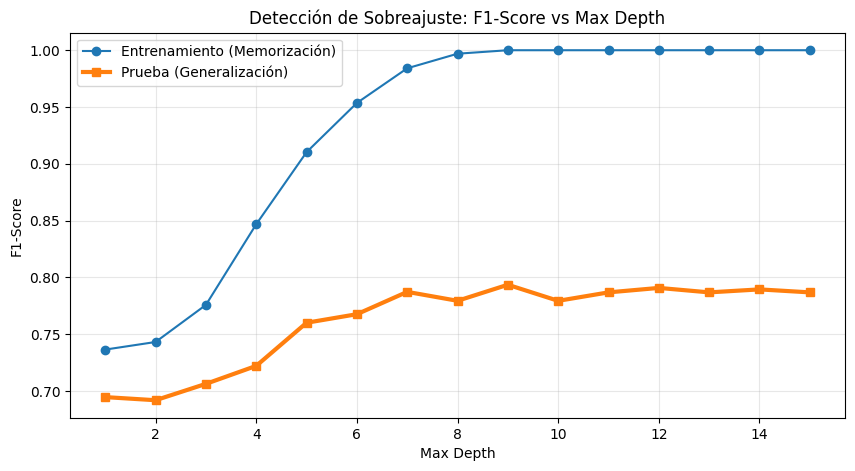

La profundidad óptima ajustada por sobreajuste es: 9
Evaluando min_samples_leaf...


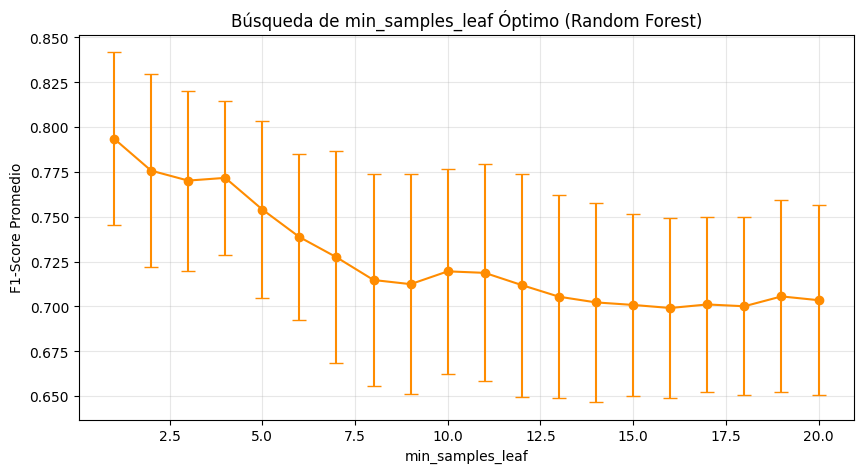

El min_samples_leaf óptimo ajustado por sobreajuste es: 4


In [5]:
depths = range(1, 16)
train_results = []
test_results = []

print("Calculando curva de complejidad para max_depth...")

for d in depths:
    t_iter, v_iter = [], []
    for i in range(10): # 10 Validaciones independientes
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        
        # Modelo con n_estimators=100 (base) y balanceo de pesos
        rf = RandomForestClassifier(n_estimators=100, max_depth=d, 
                                    class_weight='balanced', random_state=42)
        rf.fit(xt, yt)
        
        t_iter.append(f1_score(yt, rf.predict(xt)))
        v_iter.append(f1_score(yv, rf.predict(xv)))
    
    train_results.append(np.mean(t_iter))
    test_results.append(np.mean(v_iter))

depth_gap = np.maximum(0, np.array(train_results) - np.array(test_results))
depth_adjusted_scores = np.array(test_results) - 0.5 * depth_gap

# Visualización de la curva
def plot_depth_curve():
    plt.figure(figsize=(10, 5))
    plt.plot(depths, train_results, label='Entrenamiento (Memorización)', marker='o')
    plt.plot(depths, test_results, label='Prueba (Generalización)', marker='s', linewidth=3)
    plt.title("Detección de Sobreajuste: F1-Score vs Max Depth")
    plt.xlabel("Max Depth")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_depth_curve()

opt_depth = depths[np.argmax(depth_adjusted_scores)]
print(f"La profundidad óptima ajustada por sobreajuste es: {opt_depth}")

leaf_values = range(1, 21)
leaf_scores = []
leaf_stds = []
leaf_train_scores = []
leaf_adjusted_scores = []

print("Evaluando min_samples_leaf...")
for leaf in leaf_values:
    train_iter, test_iter = [], []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        rf = RandomForestClassifier(n_estimators=100, max_depth=opt_depth, 
                                    min_samples_leaf=leaf,
                                    class_weight='balanced', random_state=42)
        rf.fit(xt, yt)
        train_iter.append(f1_score(yt, rf.predict(xt)))
        test_iter.append(f1_score(yv, rf.predict(xv)))
    leaf_train_scores.append(np.mean(train_iter))
    leaf_scores.append(np.mean(test_iter))
    leaf_stds.append(np.std(test_iter))
    leaf_gap = max(0, np.mean(train_iter) - np.mean(test_iter))
    leaf_adjusted_scores.append(np.mean(test_iter) - 0.5 * leaf_gap)

plt.figure(figsize=(10, 5))
plt.errorbar(leaf_values, leaf_scores, yerr=leaf_stds, fmt='-o', color='darkorange', capsize=5)
plt.title("Búsqueda de min_samples_leaf Óptimo (Random Forest)")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = leaf_values[np.argmax(leaf_adjusted_scores)]
print(f"El min_samples_leaf óptimo ajustado por sobreajuste es: {best_leaf}")


Generando evaluación final con 10 matrices de confusión...


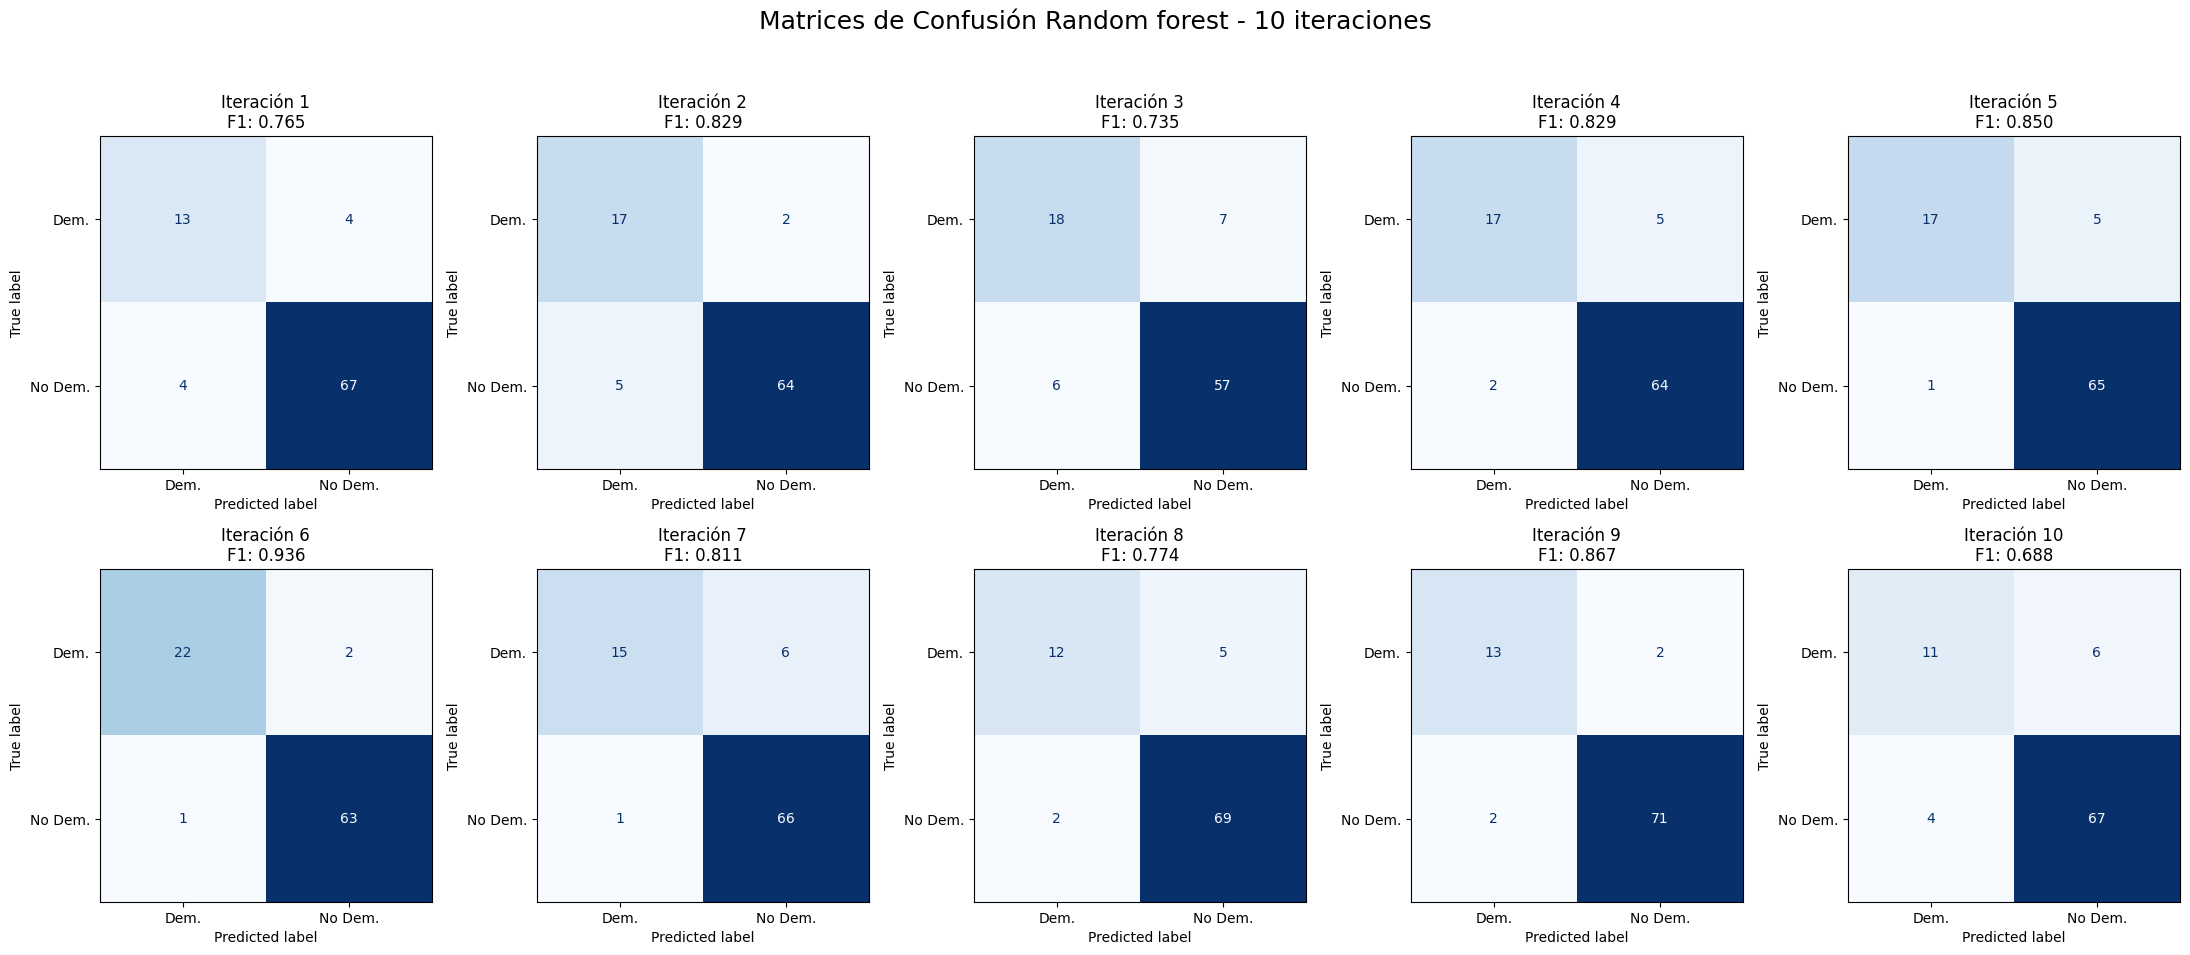

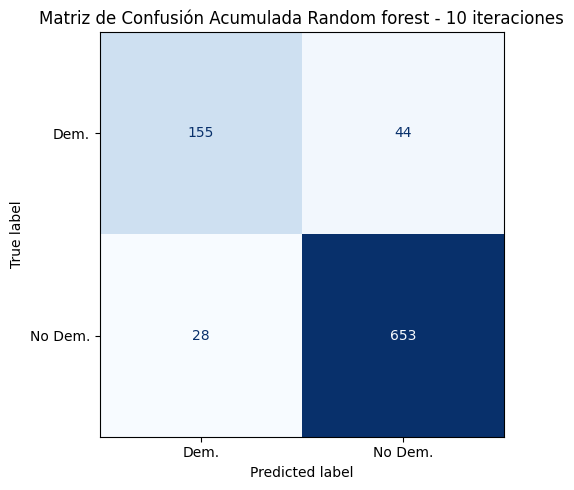


--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.9182 ± 0.0304
PREC                      | 0.8478 ± 0.0819
REC                       | 0.7775 ± 0.0841
F1                        | 0.8083 ± 0.0674
AUC                       | 0.9630 ± 0.0150


In [12]:
final_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("\nGenerando evaluación final con 10 matrices de confusión...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Modelo optimizado
    final_rf = RandomForestClassifier(n_estimators=100, 
                                      max_depth=opt_depth, 
                                      min_samples_leaf=3,
                                      random_state=42)
    final_rf.fit(X_train, y_train)
    
    y_pred = final_rf.predict(X_test)
    y_proba = final_rf.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_metrics['acc'].append(accuracy_score(y_test, y_pred))
    final_metrics['prec'].append(precision_score(y_test, y_pred))
    final_metrics['rec'].append(recall_score(y_test, y_pred))
    final_metrics['f1'].append(f1_score(y_test, y_pred))
    final_metrics['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_metrics['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Random forest - 10 iteraciones", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Random forest - 10 iteraciones')
plt.tight_layout()
plt.show()

# Reporte Estadístico Final (Media ± DE) [3]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_metrics:
    print(f"{m.upper():<25} | {np.mean(final_metrics[m]):.4f} ± {np.std(final_metrics[m]):.4f}")
print("="*55)


Generando evaluación final con 10 matrices de confusión...


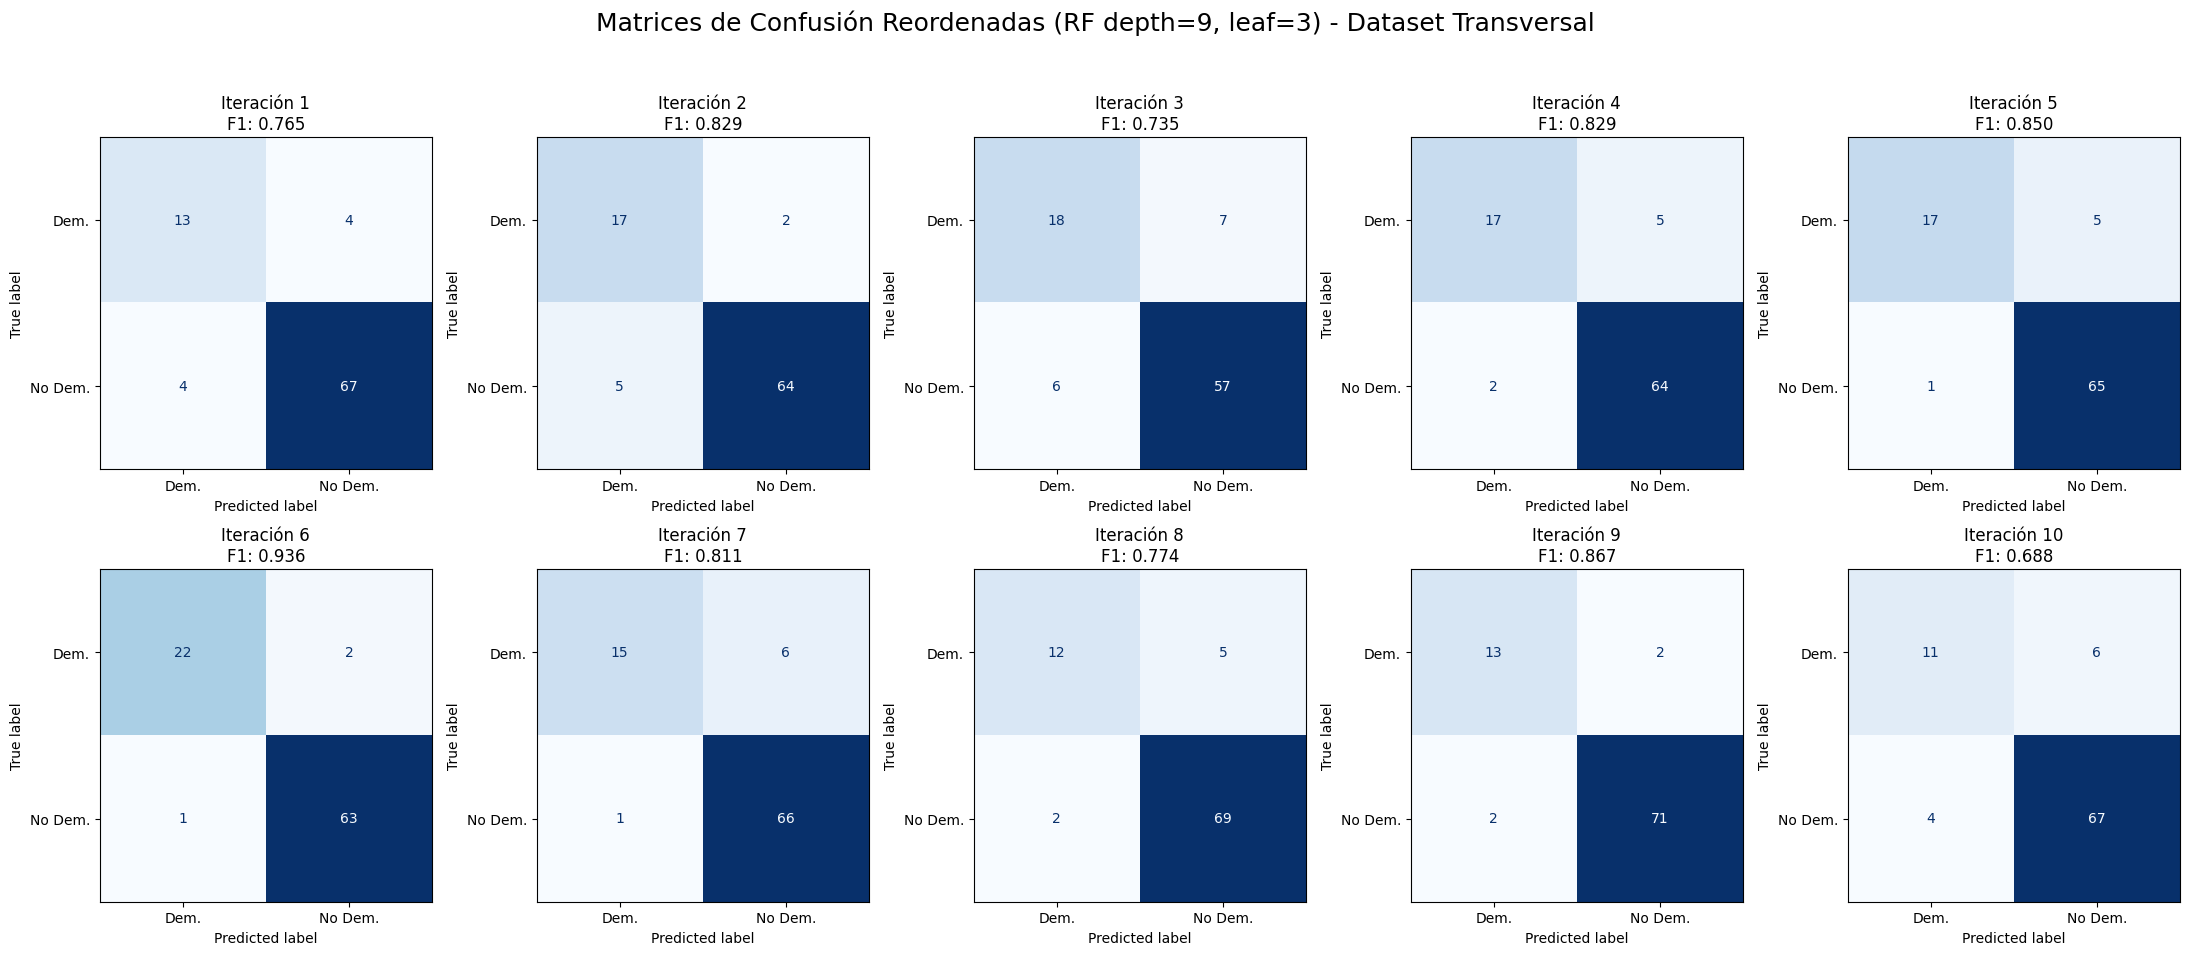

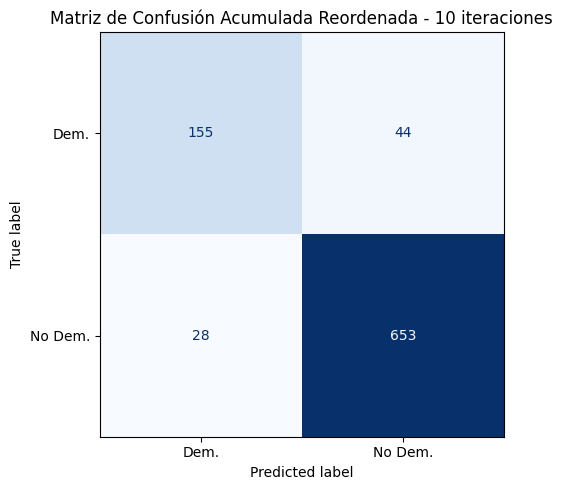


--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.9182 ± 0.0304
PREC                      | 0.8478 ± 0.0819
REC                       | 0.7775 ± 0.0841
F1                        | 0.8083 ± 0.0674
AUC                       | 0.9630 ± 0.0150


In [11]:
final_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("\nGenerando evaluación final con 10 matrices de confusión...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Modelo optimizado
    final_rf = RandomForestClassifier(n_estimators=100, 
                                      max_depth=opt_depth, 
                                      min_samples_leaf=best_leaf,
                                      random_state=42)
    final_rf.fit(X_train, y_train)
    
    y_pred = final_rf.predict(X_test)
    y_proba = final_rf.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_metrics['acc'].append(accuracy_score(y_test, y_pred))
    final_metrics['prec'].append(precision_score(y_test, y_pred))
    final_metrics['rec'].append(recall_score(y_test, y_pred))
    final_metrics['f1'].append(f1_score(y_test, y_pred))
    final_metrics['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_metrics['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (RF depth={opt_depth}, leaf={best_leaf}) - Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()


# Reporte Estadístico Final (Media ± DE) [3]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_metrics:
    print(f"{m.upper():<25} | {np.mean(final_metrics[m]):.4f} ± {np.std(final_metrics[m]):.4f}")
print("="*55)


Generando evaluación final con 10 matrices de confusión...


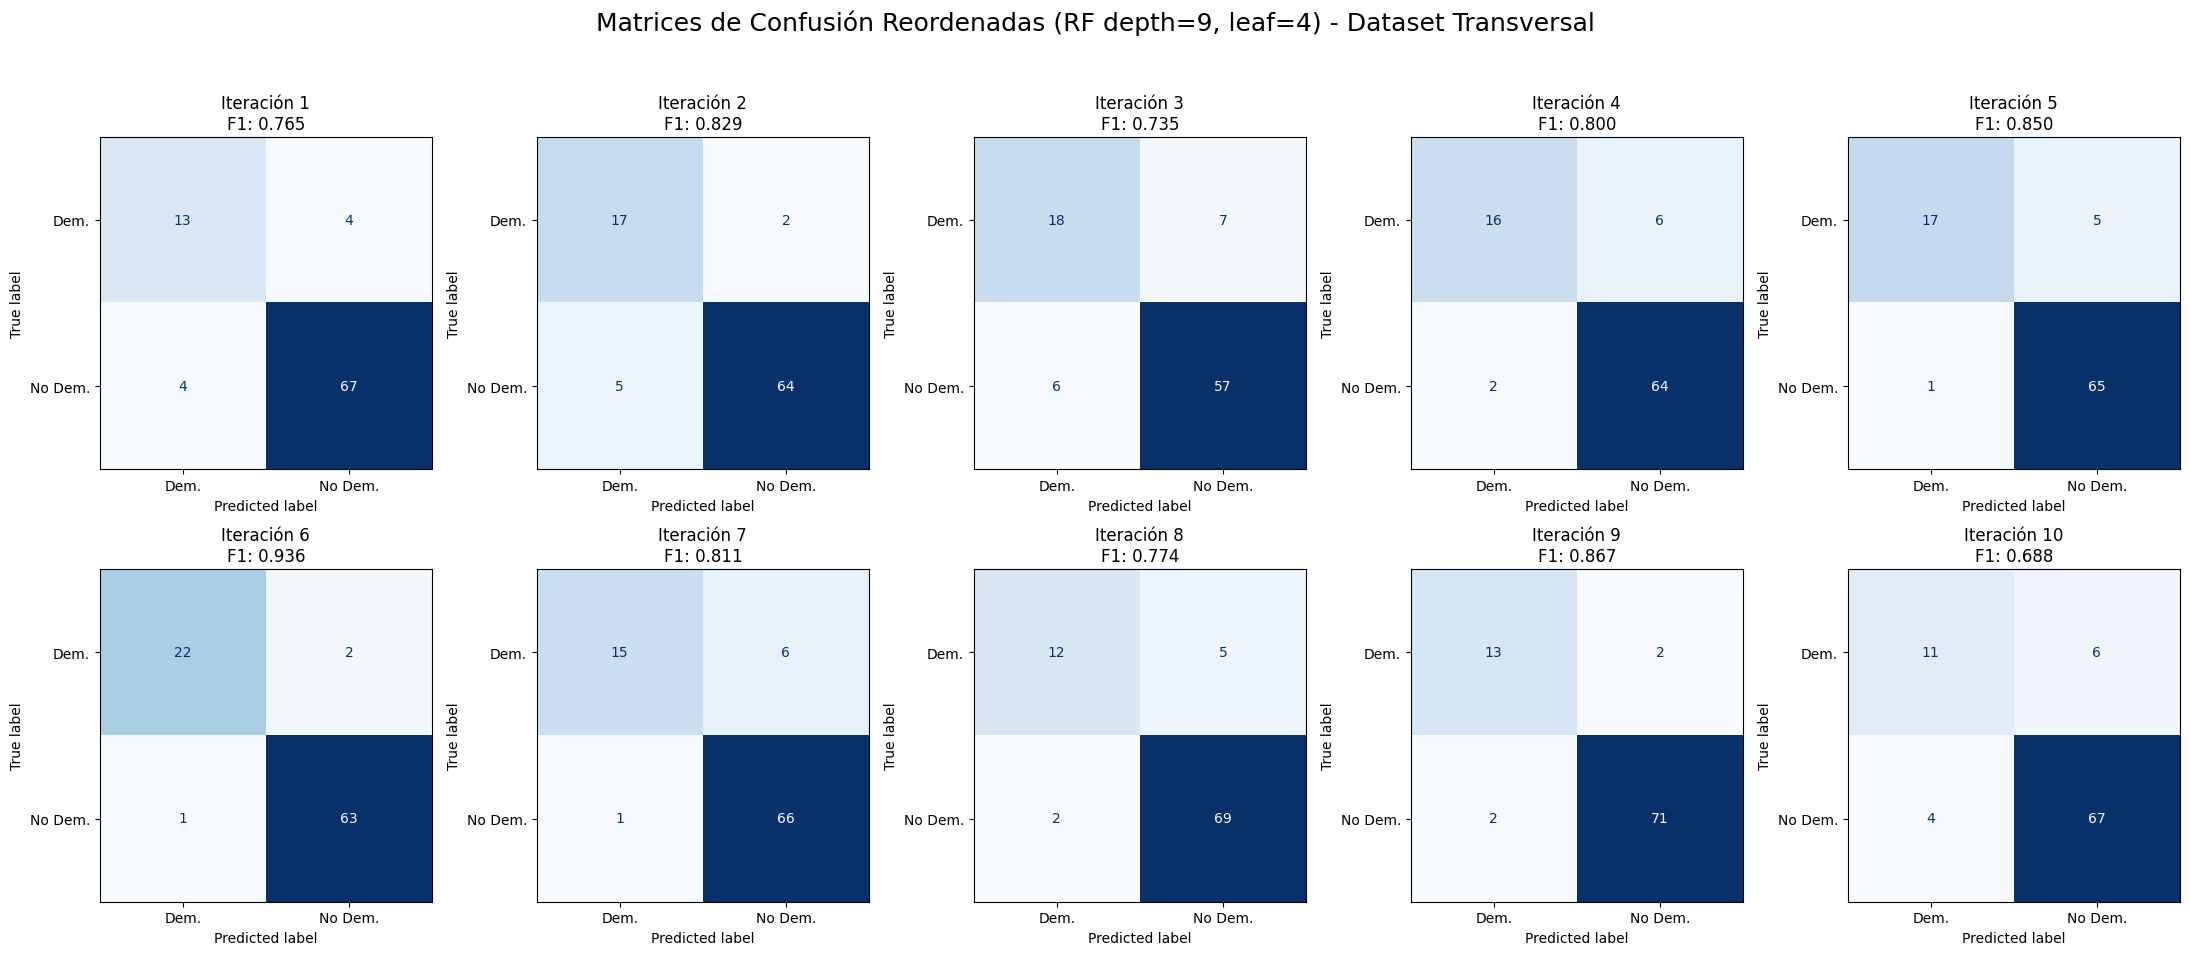


--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.9170 ± 0.0305
PREC                      | 0.8472 ± 0.0816
REC                       | 0.7730 ± 0.0854
F1                        | 0.8054 ± 0.0671
AUC                       | 0.9652 ± 0.0150


In [8]:
final_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("\nGenerando evaluación final con 10 matrices de confusión...")

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Modelo optimizado
    final_rf = RandomForestClassifier(n_estimators=100, 
                                      max_depth=opt_depth, 
                                      min_samples_leaf=best_leaf,
                                      random_state=42)
    final_rf.fit(X_train, y_train)
    
    y_pred = final_rf.predict(X_test)
    y_proba = final_rf.predict_proba(X_test)[:, 1]
    
    # Registro de métricas
    final_metrics['acc'].append(accuracy_score(y_test, y_pred))
    final_metrics['prec'].append(precision_score(y_test, y_pred))
    final_metrics['rec'].append(recall_score(y_test, y_pred))
    final_metrics['f1'].append(f1_score(y_test, y_pred))
    final_metrics['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {final_metrics['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (RF depth={opt_depth}, leaf={best_leaf}) - Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Reporte Estadístico Final (Media ± DE) [3]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL RANDOM FOREST (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in final_metrics:
    print(f"{m.upper():<25} | {np.mean(final_metrics[m]):.4f} ± {np.std(final_metrics[m]):.4f}")
print("="*55)

Evaluando impacto de la fragmentación (min_samples_leaf)...


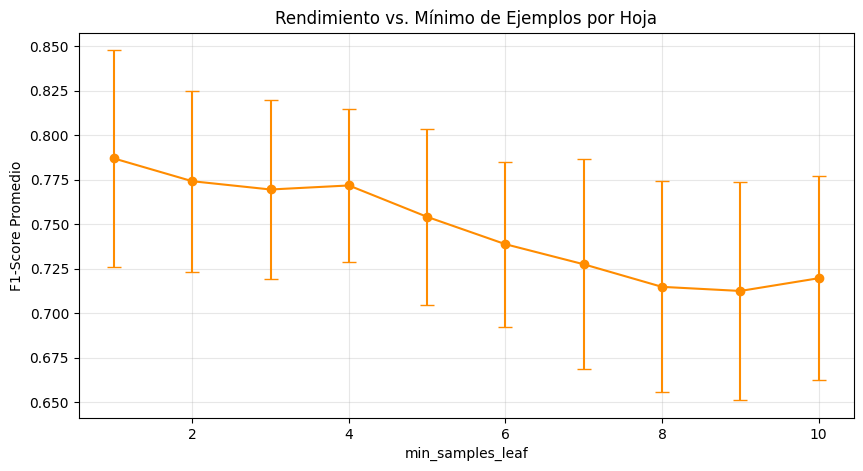

El min_samples_leaf recomendado es: 1


In [9]:
leaf_values = range(1, 11)
leaf_scores = []
leaf_stds = []

print("Evaluando impacto de la fragmentación (min_samples_leaf)...")

for l in leaf_values:
    iter_f1 = []
    for i in range(10): # 10 Validaciones independientes [9]
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        
        # Modelo con n_estimators=100 y pesos balanceados para el desbalance [10]
        rf = RandomForestClassifier(n_estimators=100, 
                                    min_samples_leaf=l,
                                    class_weight='balanced', 
                                    random_state=42)
        rf.fit(xt, yt)
        iter_f1.append(f1_score(yv, rf.predict(xv)))
        
    leaf_scores.append(np.mean(iter_f1))
    leaf_stds.append(np.std(iter_f1))

# Visualización de la curva de desempeño
plt.figure(figsize=(10, 5))
plt.errorbar(leaf_values, leaf_scores, yerr=leaf_stds, fmt='-o', color='darkorange', capsize=5)
plt.title("Rendimiento vs. Mínimo de Ejemplos por Hoja")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = leaf_values[np.argmax(leaf_scores)]
print(f"El min_samples_leaf recomendado es: {best_leaf}")

Evaluando impacto de la fragmentación (min_samples_leaf)...


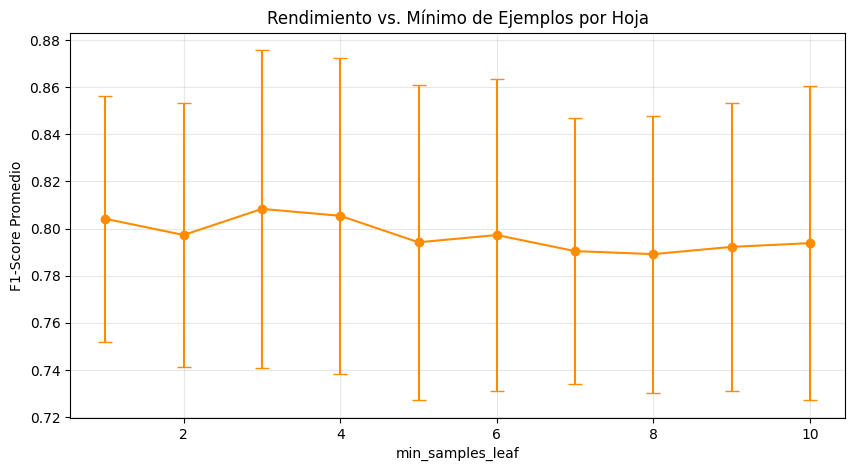

El min_samples_leaf recomendado es: 3


In [10]:
leaf_values = range(1, 11)
leaf_scores = []
leaf_stds = []

print("Evaluando impacto de la fragmentación (min_samples_leaf)...")

for l in leaf_values:
    iter_f1 = []
    for i in range(10): # 10 Validaciones independientes [9]
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        
        # Modelo con n_estimators=100 y pesos balanceados para el desbalance [10]
        rf = RandomForestClassifier(n_estimators=100, 
                                    min_samples_leaf=l, 
                                    random_state=42)
        rf.fit(xt, yt)
        iter_f1.append(f1_score(yv, rf.predict(xv)))
        
    leaf_scores.append(np.mean(iter_f1))
    leaf_stds.append(np.std(iter_f1))

# Visualización de la curva de desempeño
plt.figure(figsize=(10, 5))
plt.errorbar(leaf_values, leaf_scores, yerr=leaf_stds, fmt='-o', color='darkorange', capsize=5)
plt.title("Rendimiento vs. Mínimo de Ejemplos por Hoja")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = leaf_values[np.argmax(leaf_scores)]
print(f"El min_samples_leaf recomendado es: {best_leaf}")